# ReGRID model analysis

### Marginal opportunity cost

Last update: 12 February, 2026

Dependency: model.py

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

In [31]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'high' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

TECH_CASE = 'ccs-biomass'
if TECH_CASE == 'ccs-biomass':
    CCS_AVAILAVILITY = 2 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 2 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 0.1 # Availability of technical potential
else:
    CCS_AVAILAVILITY = 1 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 1 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 1 # Availability of technical potential

In [32]:
# Initialize a model
def get_model_name(ver=VER, year=YEAR, pathway=PATHWAY, term=TERM, step=STEP, boundary=BOUNDARY, network=NETWORK, nuclear=NUCLEAR_AVAILABILITY, potential=POTENTIAL_AVAILABILITY, potential_case=POTENTIAL_CASE, cost_case=COST_CASE, tech_case=TECH_CASE):
    return f"ReGRID2_{ver}_{year}_{pathway}_{term}_{step}_{boundary}_{network}_n{nuclear}_p{potential}_{potential_case}_{cost_case}_{tech_case}"

model_name = get_model_name()
print(model_name)

ReGRID2_v8_2050_C1_1y_6_japan_1741_n2_p100_high_moderate_ccs-biomass


In [33]:
# Data for analysis

# Result
dual = pd.read_csv('output/%s/dual_%s.csv' % (model_name,model_name), index_col=0, dtype={'region':str, 'time':str})
dual = dual.replace('_', '', regex=True) #Remove blank
dual = dual.replace(' ', '', regex=True) #Remove blank

# Technology dataset
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[(P['year'] == YEAR) & (P['scenario'] == COST_CASE)]

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str})
REGION = region_list.index.to_list() # All nodes

# Renewable energy temporal profiles
profile = {}
profile["solar"] = pd.read_csv('input/%sh/solar_2019.csv' % (STEP), index_col=0)
profile["onwin"] = pd.read_csv('input/%sh/onwind_2019.csv' % (STEP), index_col=0)
profile["of-fx"] = pd.read_csv('input/%sh/ofwind_2019_fixed.csv' % (STEP), index_col=0)
profile["of-fl"] = pd.read_csv('input/%sh/ofwind_2019_float.csv' % (STEP), index_col=0)
profile["river"] = pd.read_csv('input/%sh/river_2019.csv' % (STEP), index_col=0)
profile["geoth"] = pd.read_csv('input/%sh/geothermal_2019.csv' % (STEP), index_col=0)
profile["hydro"] = pd.read_csv('input/%sh/hydro_2019.csv' % (STEP), index_col=0)
potential_VRE_MW = pd.read_csv('input/potential/renewables_potential_MW_%s.csv' % POTENTIAL_CASE, index_col='code', dtype={'code':str})

# Annual capacity factor for renewables
CF_annual = {}
for res in profile.keys():
    CF_annual[res] = (profile[res] / STEP).mean()
    
# JPY -> USD
USD = 107 # TTM in 2020

In [34]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [ ]:
# Draw map

def map_plot(map_data, map_label, cmap, map_min, map_max, map_title=None, color_bar=True):

    plt.rcParams['axes.linewidth'] = 0

    # Boundary
    municipal_shapes = list(gpd.read_file("input/analysis/boundary/1741municipalities.gpkg").geometry)
    japan_shapes = list(gpd.read_file("input/analysis/boundary/Japan.gpkg").geometry)

    # Colormap
    if map_max == "max":
        color_max = map_data.max()
    else:
        color_max = map_max

    if map_min == "min":
        color_min = map_data.min()
    else:
        color_min = map_min

    norm = mcolors.Normalize(vmin=color_min, vmax=color_max)

    # Map
    fig = plt.figure(figsize=(MAX_WIDTH*0.4, MAX_WIDTH*0.5), dpi=1200)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Regional polygon
    for n, city in enumerate(municipal_shapes):
        value = min(map_data.iloc[n], color_max)
        value = max(value, color_min)
        polygon_color = cmap(norm(value)) if not np.isnan(value) else "#eee"
        ax.add_geometries(city, ccrs.PlateCarree(), edgecolor=(0.5,0.5,0.5,1), facecolor=polygon_color, linewidth = 0.0, zorder=1)

    area_cood = [126.6, 147.0, 25.6, 45.9]
    ax.set_extent(area_cood, crs=ccrs.PlateCarree())
    ax.add_geometries(japan_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,1), facecolor=(0,0,0,0), linewidth = 0.05, zorder=2)

    # Gridline
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True
    gl.xlabel_style = {'fontsize': 4, 'color': "gray"}
    gl.ylabel_style = {'fontsize': 4, 'color': "gray"}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xpadding = 1
    gl.ypadding = 1
    
    # Draw
    if color_bar is True:
        heat_map = ax.imshow([[color_min],[color_max]], cmap=cmap, norm=norm)
        cbar = fig.colorbar(heat_map, shrink=0.83, aspect=40, pad=0.02, orientation='horizontal')
        cbar.set_label(map_label, fontsize=5, labelpad=3)
        cbar.ax.tick_params(labelsize=5, pad=1)
        cbar.ax.set_xscale('linear')
    else:
        map_title = map_title+'_wo-cbar'
    
    plt.axis('off')
    if map_title is not None:
        plt.savefig("output/%s/%s.png" % (model_name,map_title), bbox_inches='tight', pad_inches=0, transparent=False, dpi=3000)
        plt.savefig("output/%s/%s.pdf" % (model_name,map_title), bbox_inches='tight', pad_inches=0, dpi=300)
    plt.show()
    plt.clf()

In [36]:
# Marginal value of renewable energy = Marginal opportunity cost of area-based conservation (MOC)

RESOURCE = ['onwin','solar','of-fx','of-fl','geoth','river']
VRE = ['solar','onwin','of-fx','of-fl']

MOC_kWh = {}
MOC_ha = {}
for res in RESOURCE:
    MOC_kWh[res] = dual[(dual.id == 'res') & (dual.general == res)][['region','value']].astype({'region':str}).set_index(['region'])['value'] * -1 # million JPY/MWh
for res in VRE:
    MOC_ha[res] = MOC_kWh[res] * CF_annual[res] * 8760 / P['land'][res] / USD # M-JPY/MWh -> M-USD/km2
    MOC_ha[res] = MOC_ha[res] * 1000000 / 100 # M-USD/km2 -> USD/ha
    MOC_ha[res] = MOC_ha[res] * CF_annual[res].apply(lambda x: 1 if x > 0 else np.nan)

# Export
MOC_ha_pd = pd.DataFrame(MOC_ha)
MOC_ha_pd.to_csv("output/%s/renewable_USD-ha_%s.csv" % (model_name, model_name))
MOC_ha_pd

,solar,onwin,of-fx,of-fl
region,,,,
11002,25917.016523,18775.157228,23883.336245,NaN
12025,37875.253643,19936.248041,28837.275656,29521.218523
12033,24832.157051,18783.512021,28503.089966,29745.929793
12041,10882.019691,9577.013126,NaN,NaN
12050,27873.064234,10299.232425,28546.019444,27508.486811
...,...,...,...,...
473618,517741.636565,290957.854253,NaN,NaN
473626,116677.992040,23642.545934,NaN,NaN
473758,227940.515304,63517.807824,NaN,-0.000000


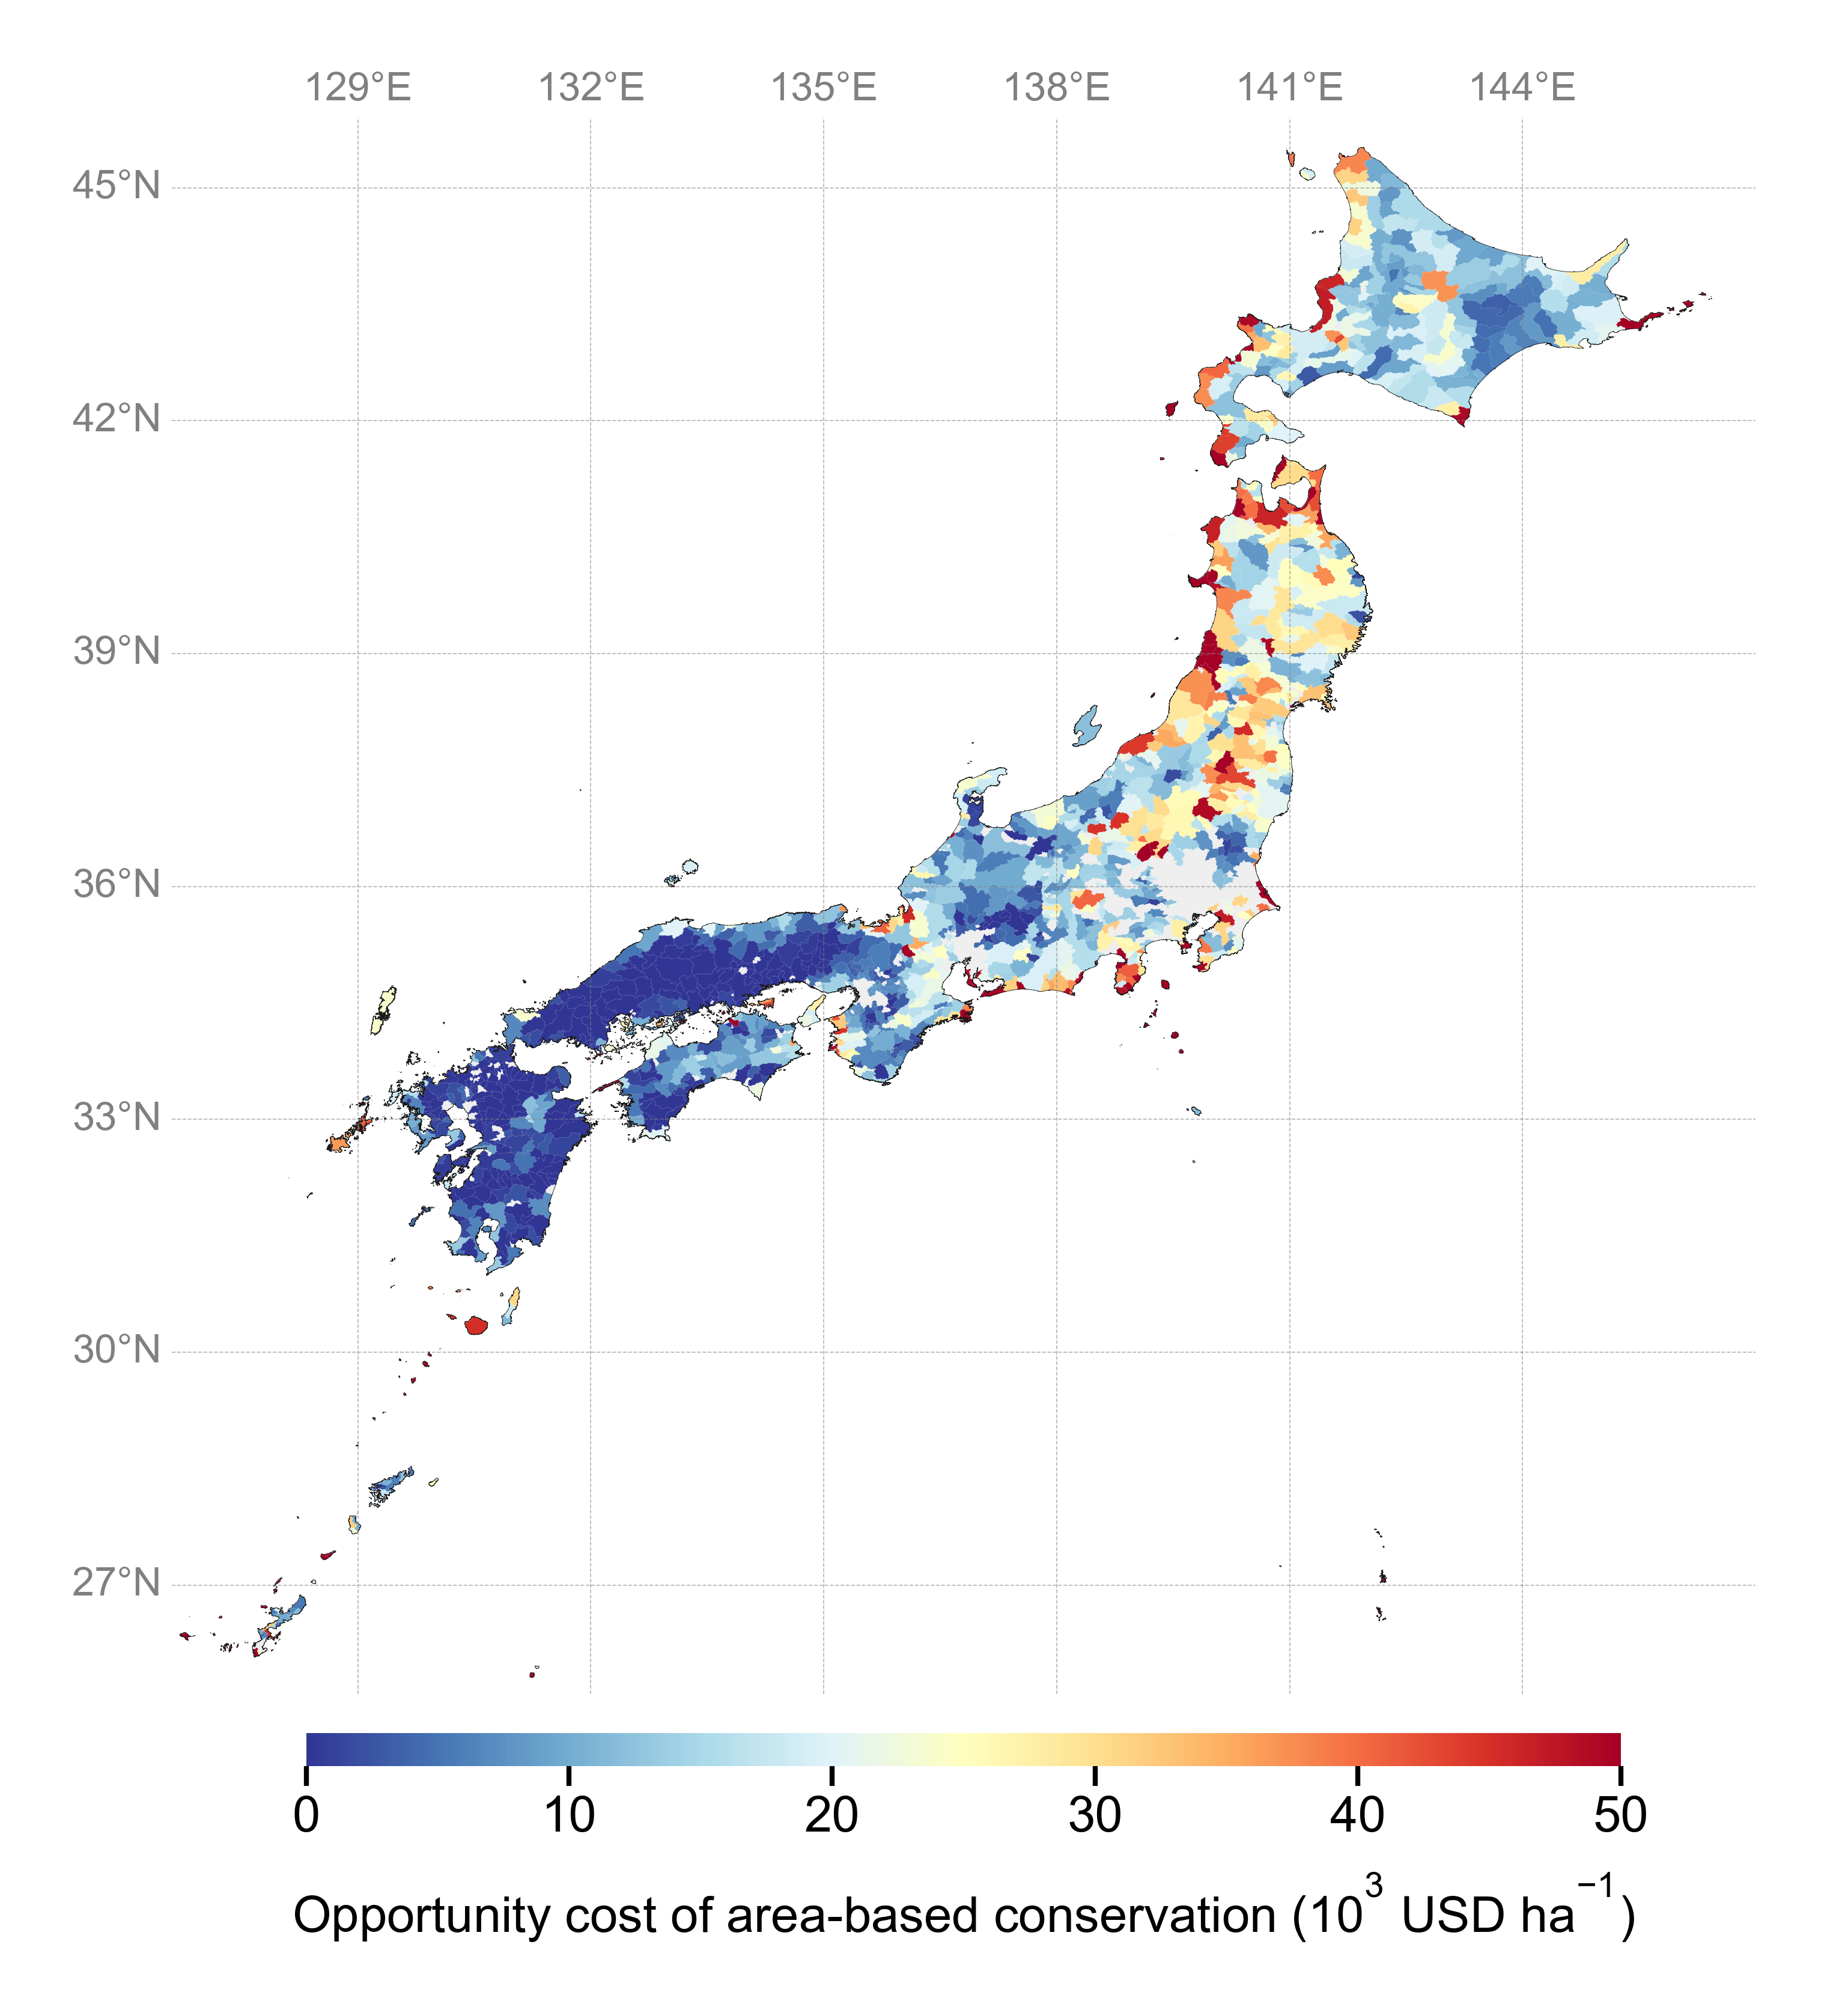

<Figure size 640x480 with 0 Axes>

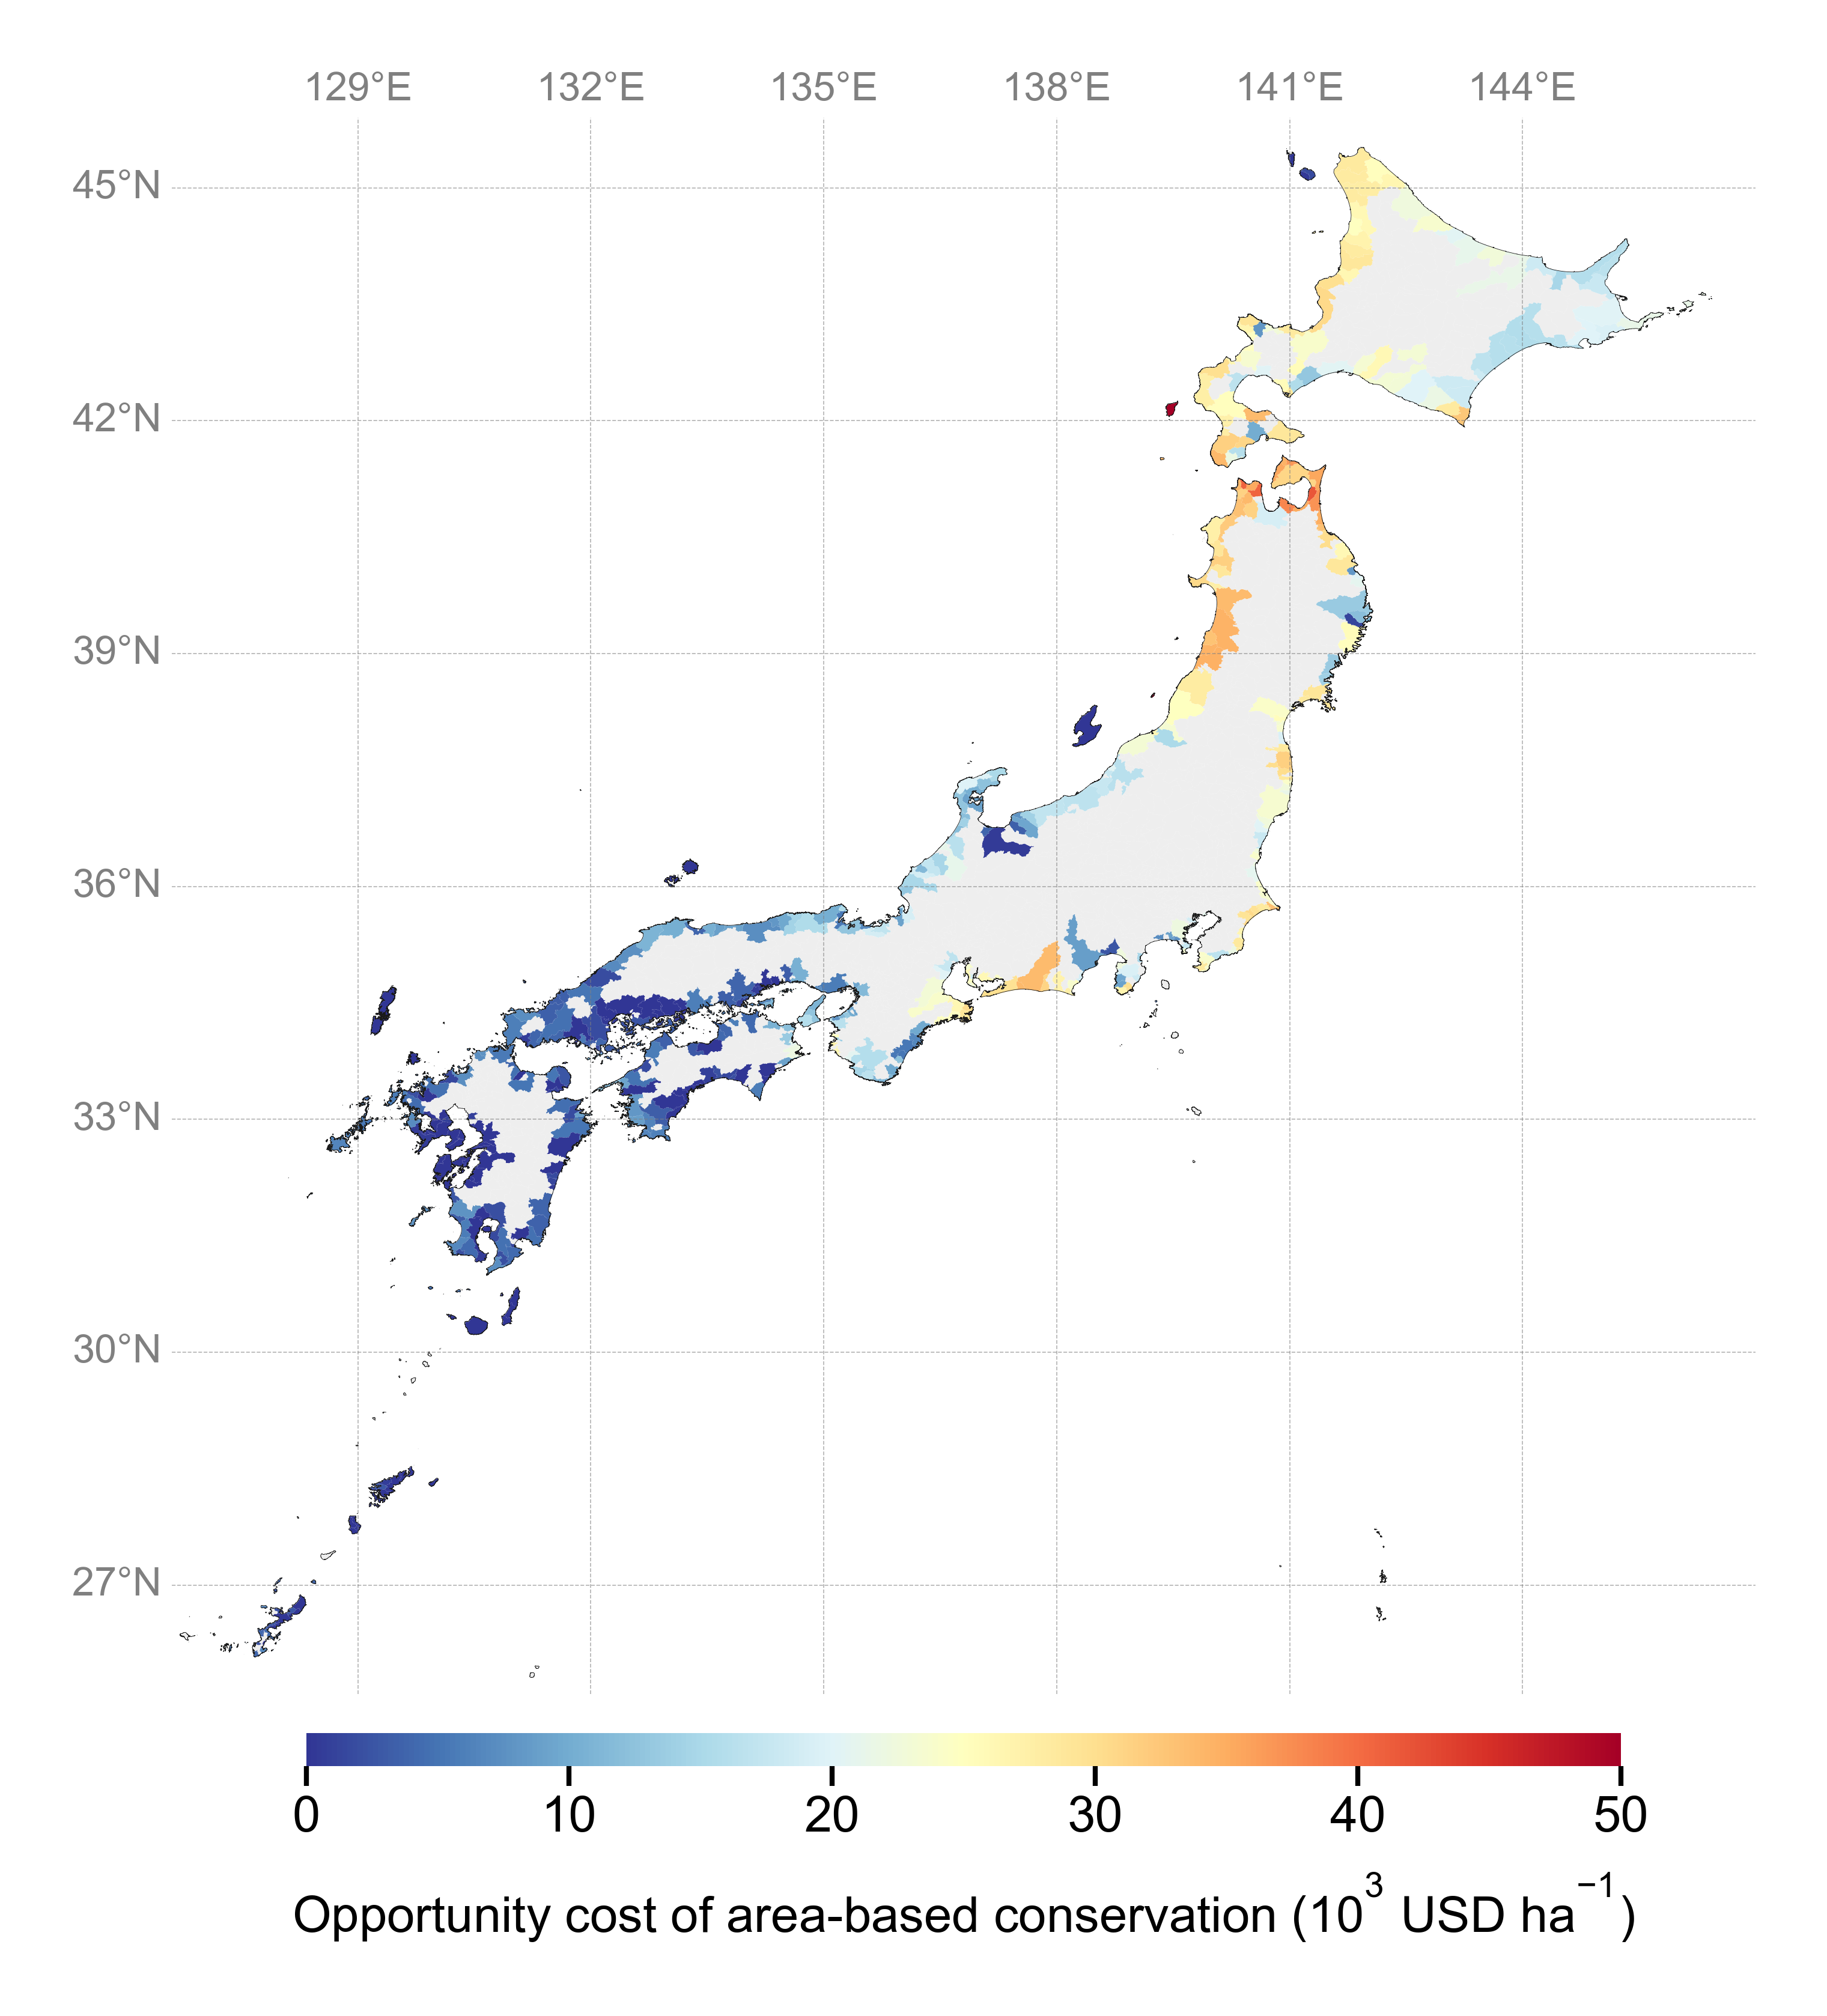

<Figure size 640x480 with 0 Axes>

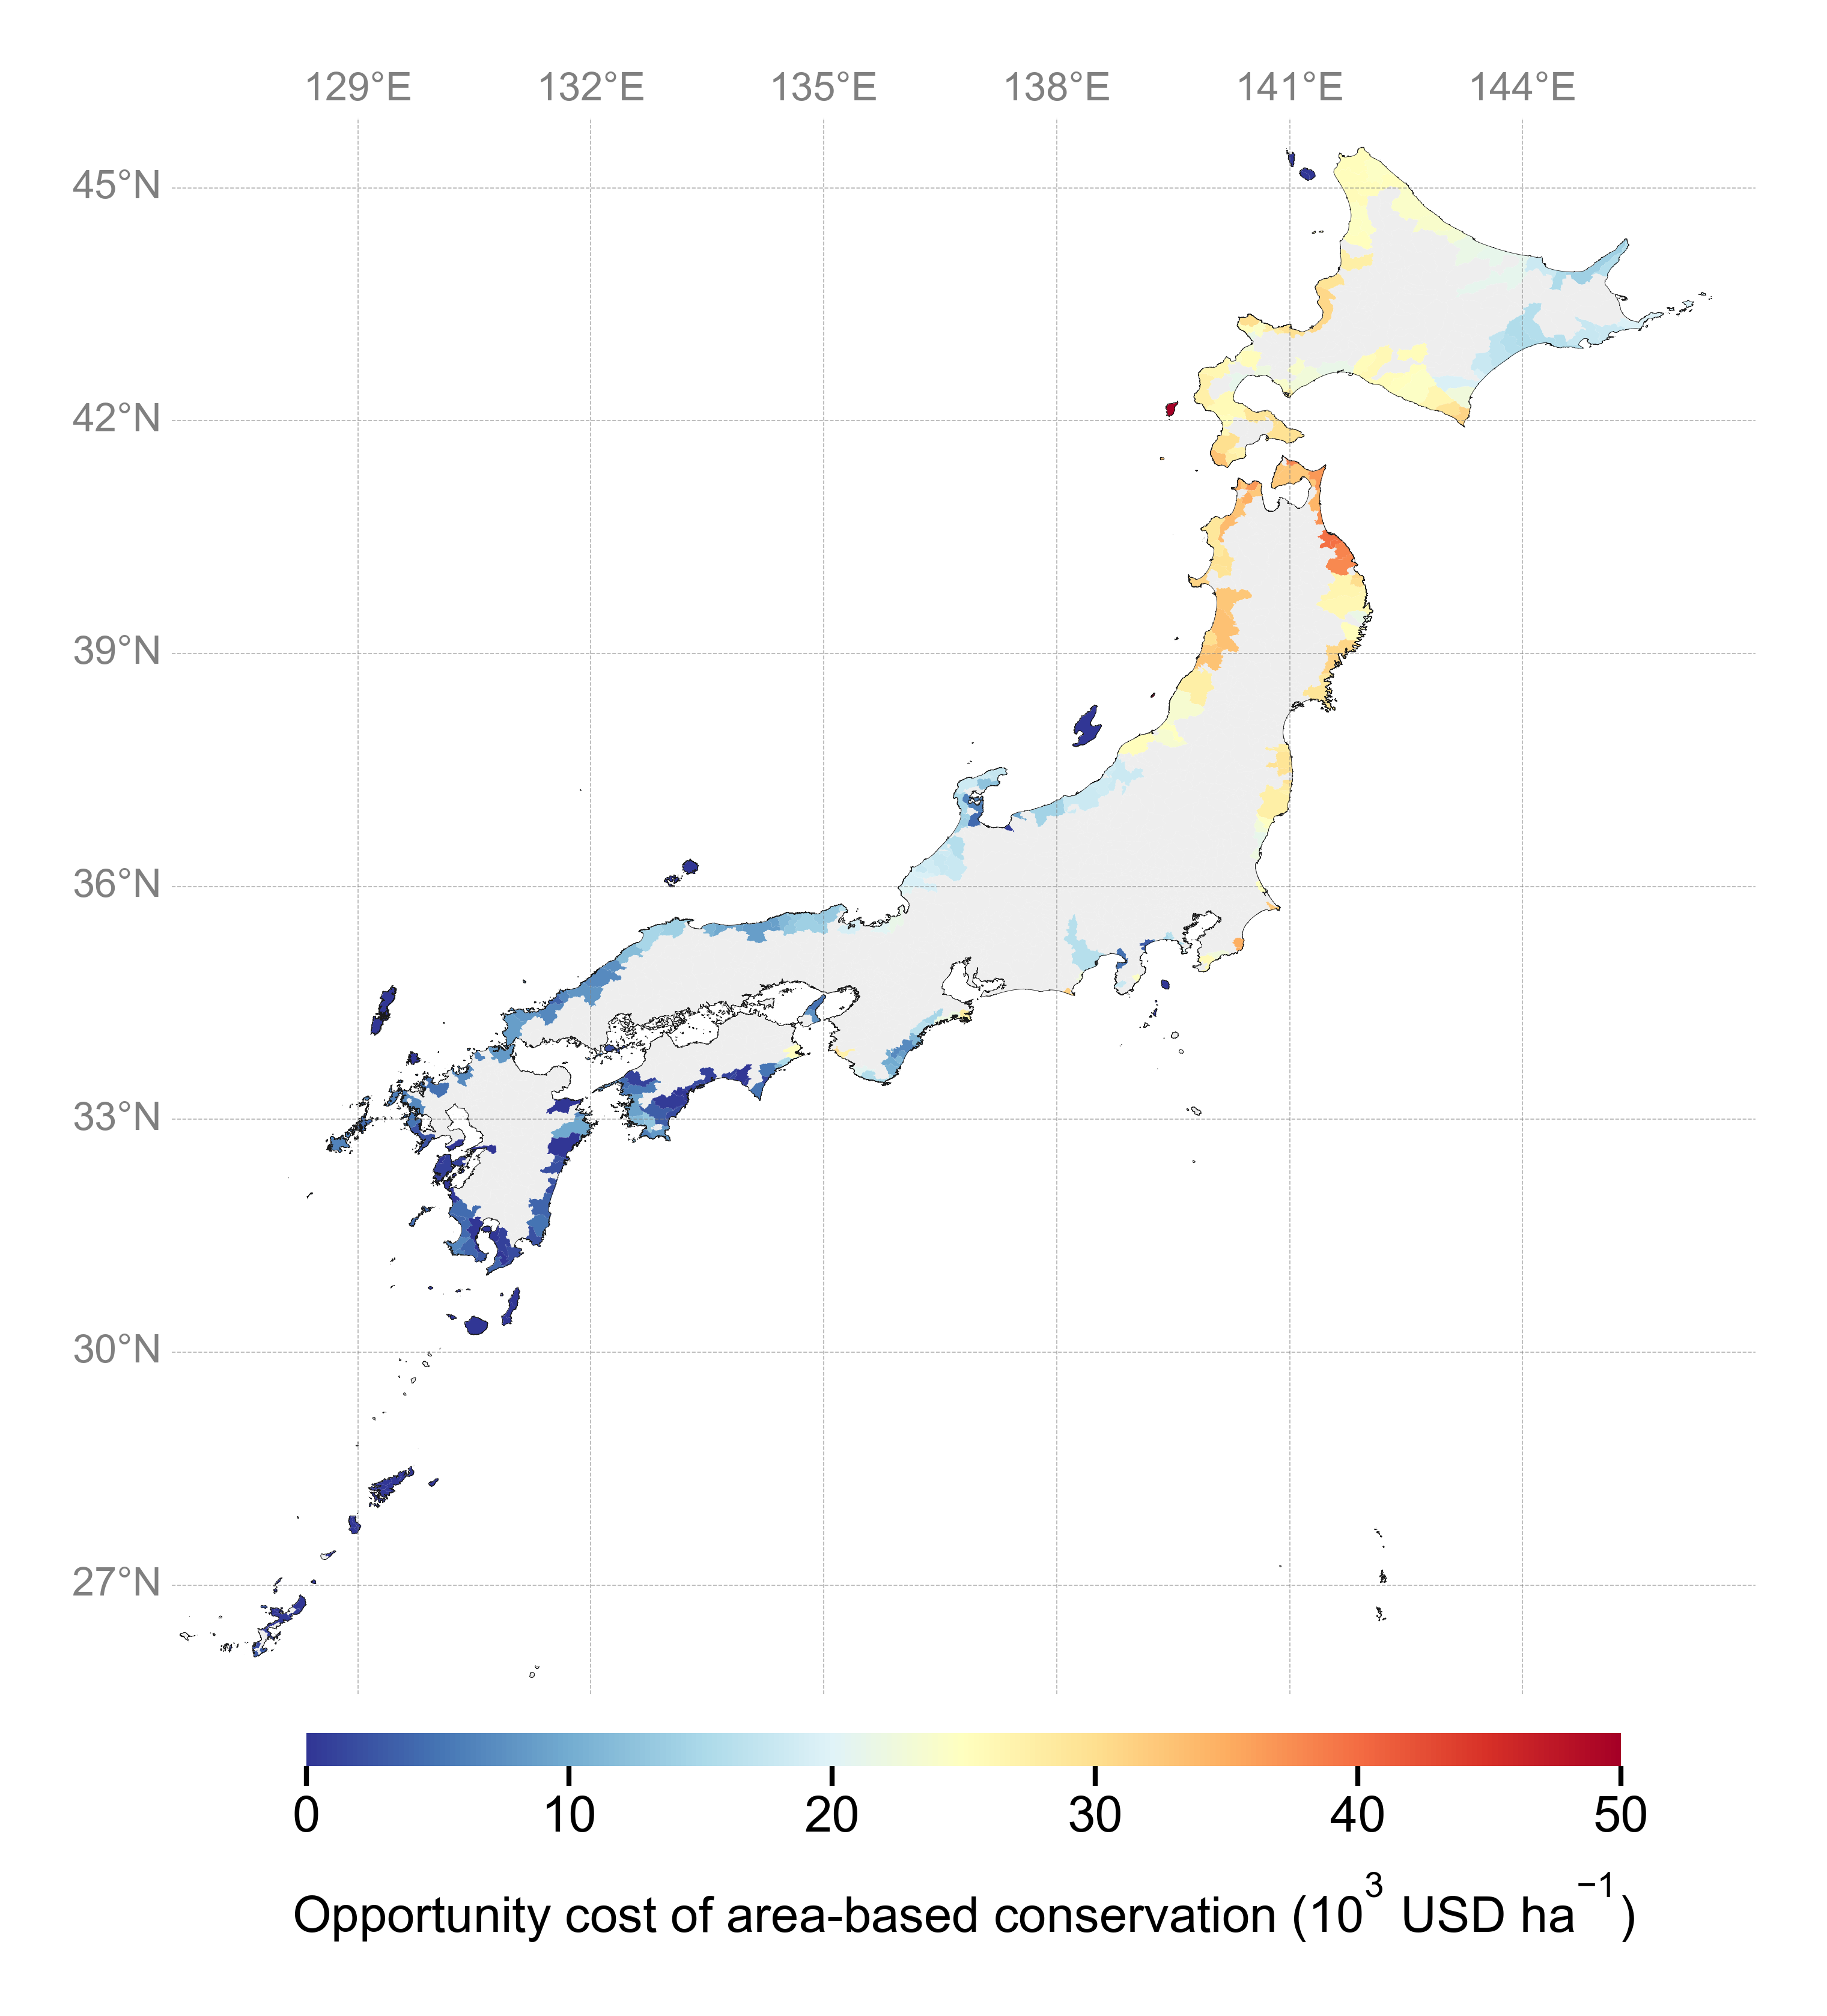

<Figure size 640x480 with 0 Axes>

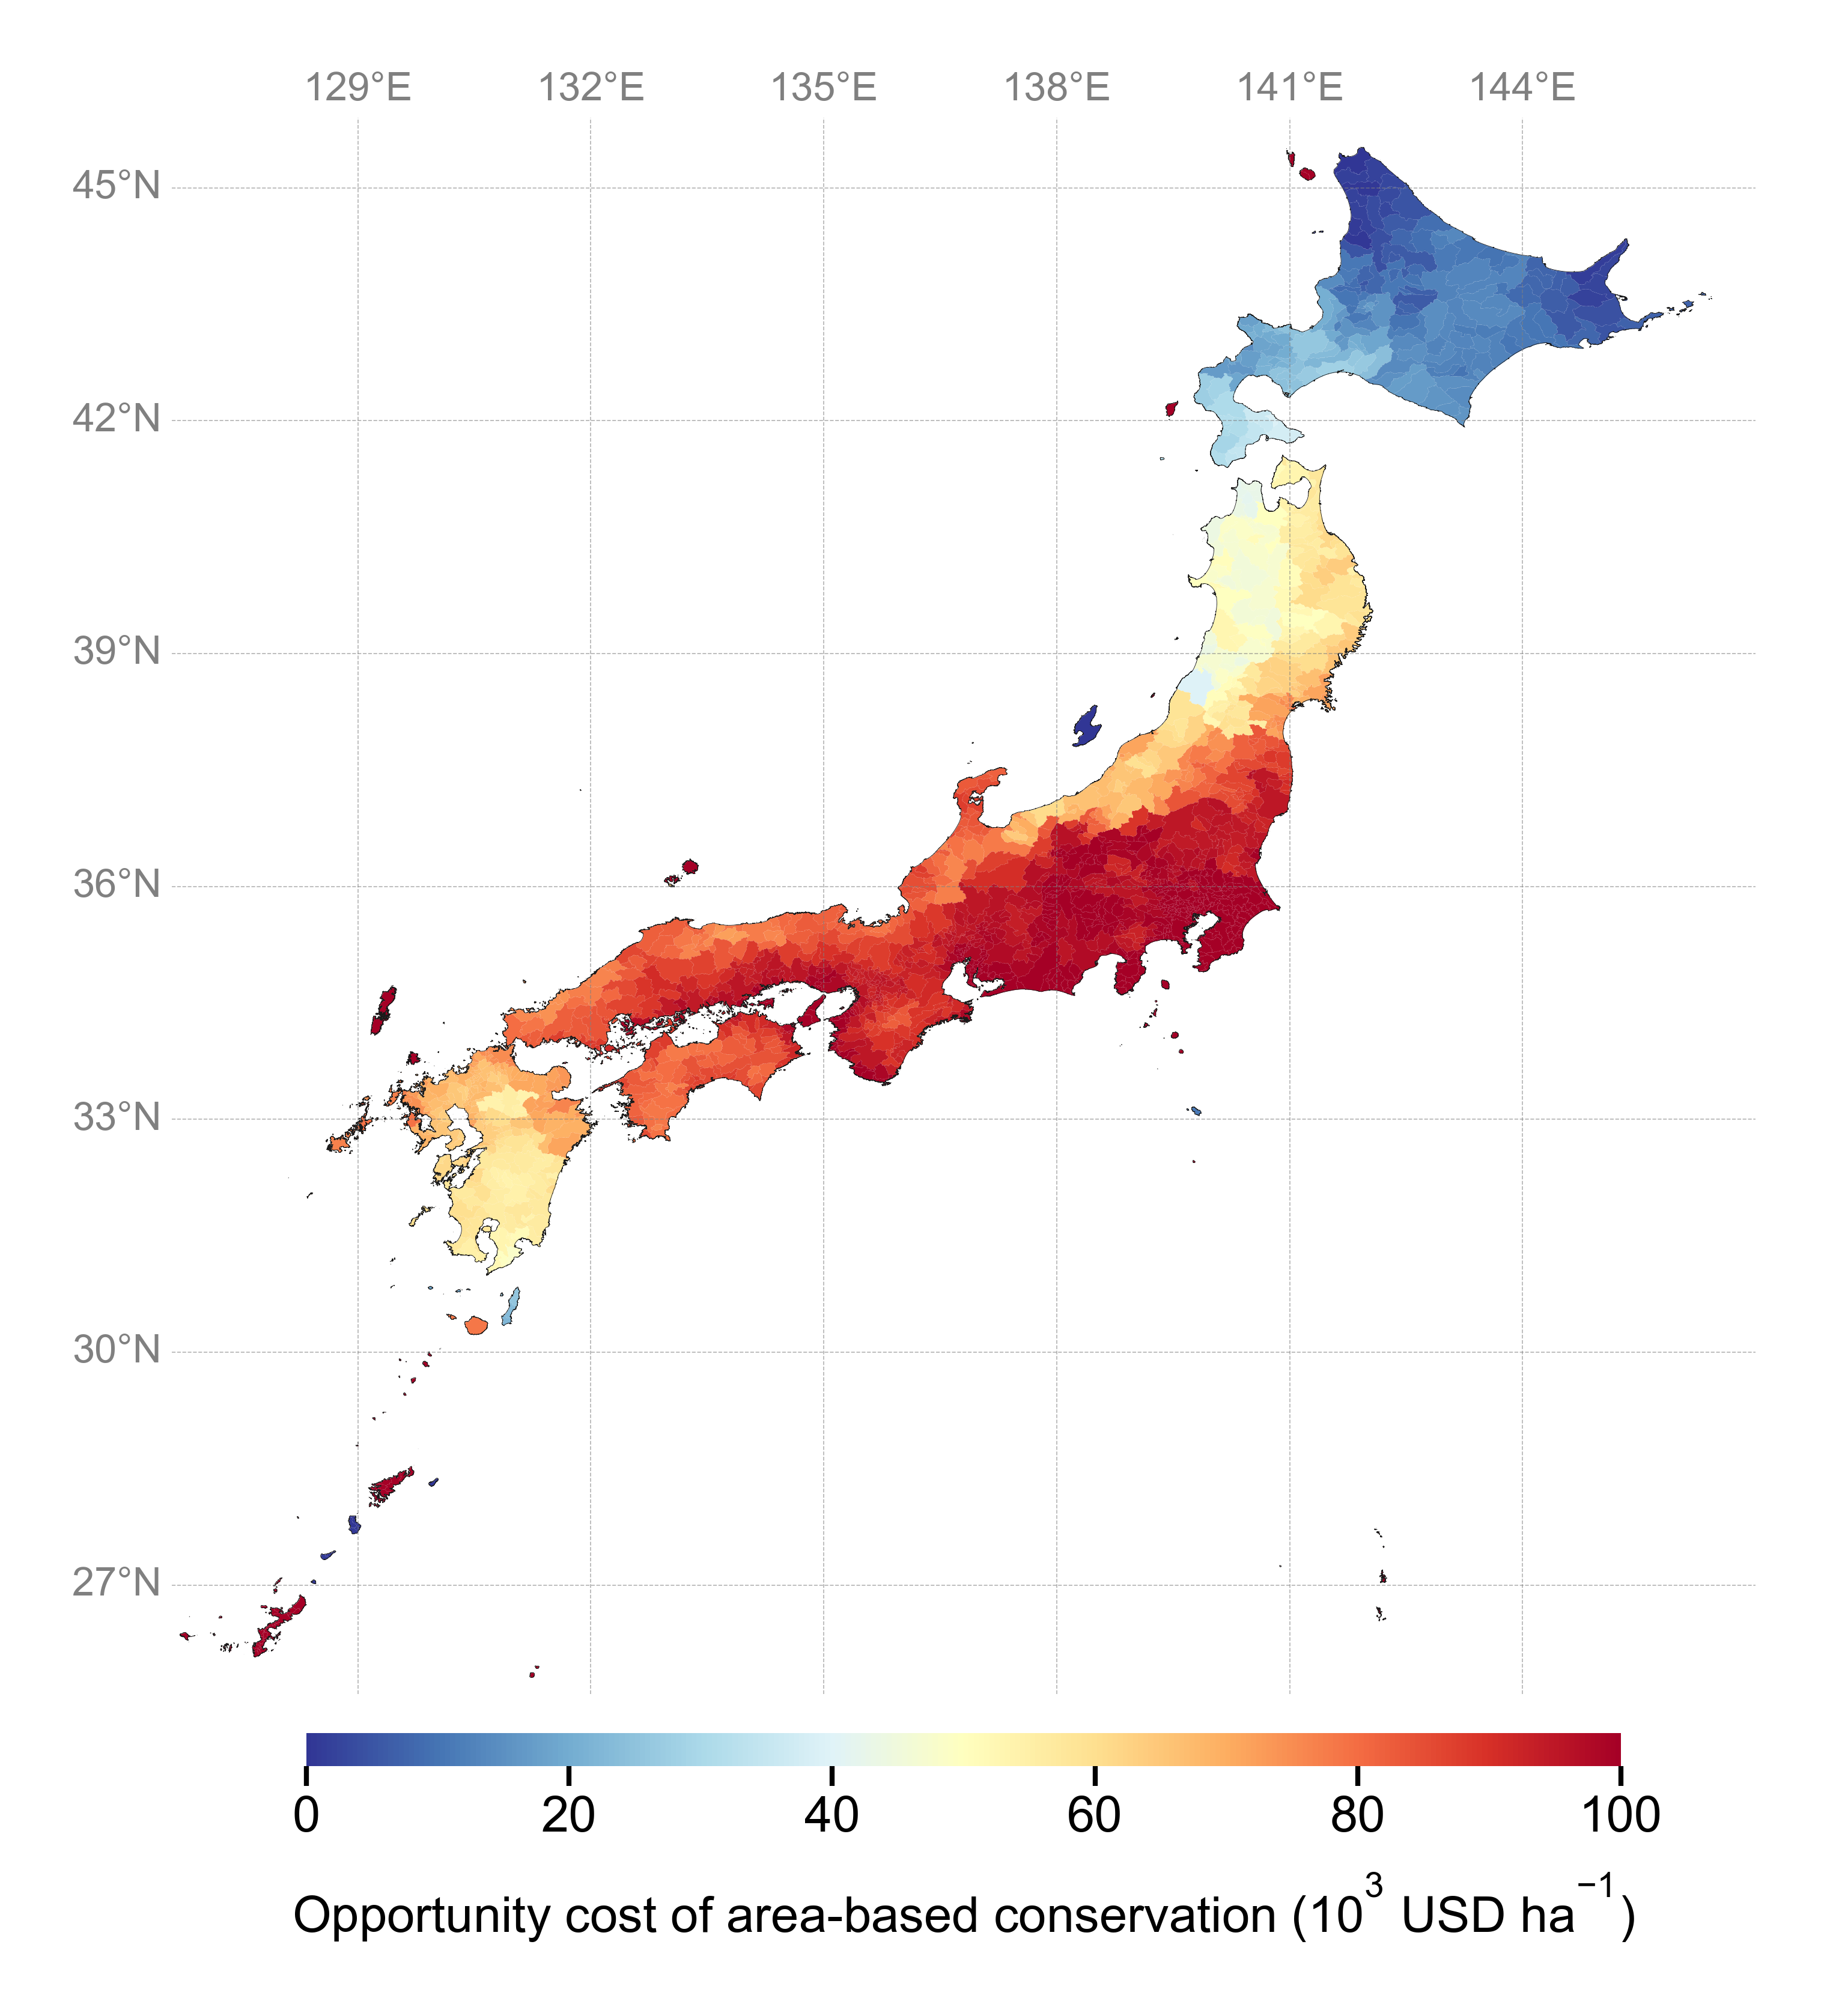

<Figure size 640x480 with 0 Axes>

In [37]:
# Map

for res in ['onwin','of-fx','of-fl']:
    map_plot(MOC_ha[res]/1000, 'Opportunity cost of area-based conservation (10$^{3}$ USD ha$^{-1}$)', cm.RdYlBu_r, 0, 50, f'map_USD-ha_{res}_{model_name}_50', color_bar=True)

for res in ['solar']:
    map_plot(MOC_ha[res]/1000, 'Opportunity cost of area-based conservation (10$^{3}$ USD ha$^{-1}$)', cm.RdYlBu_r, 0, 100, f'map_USD-ha_{res}_{model_name}_100', color_bar=True)

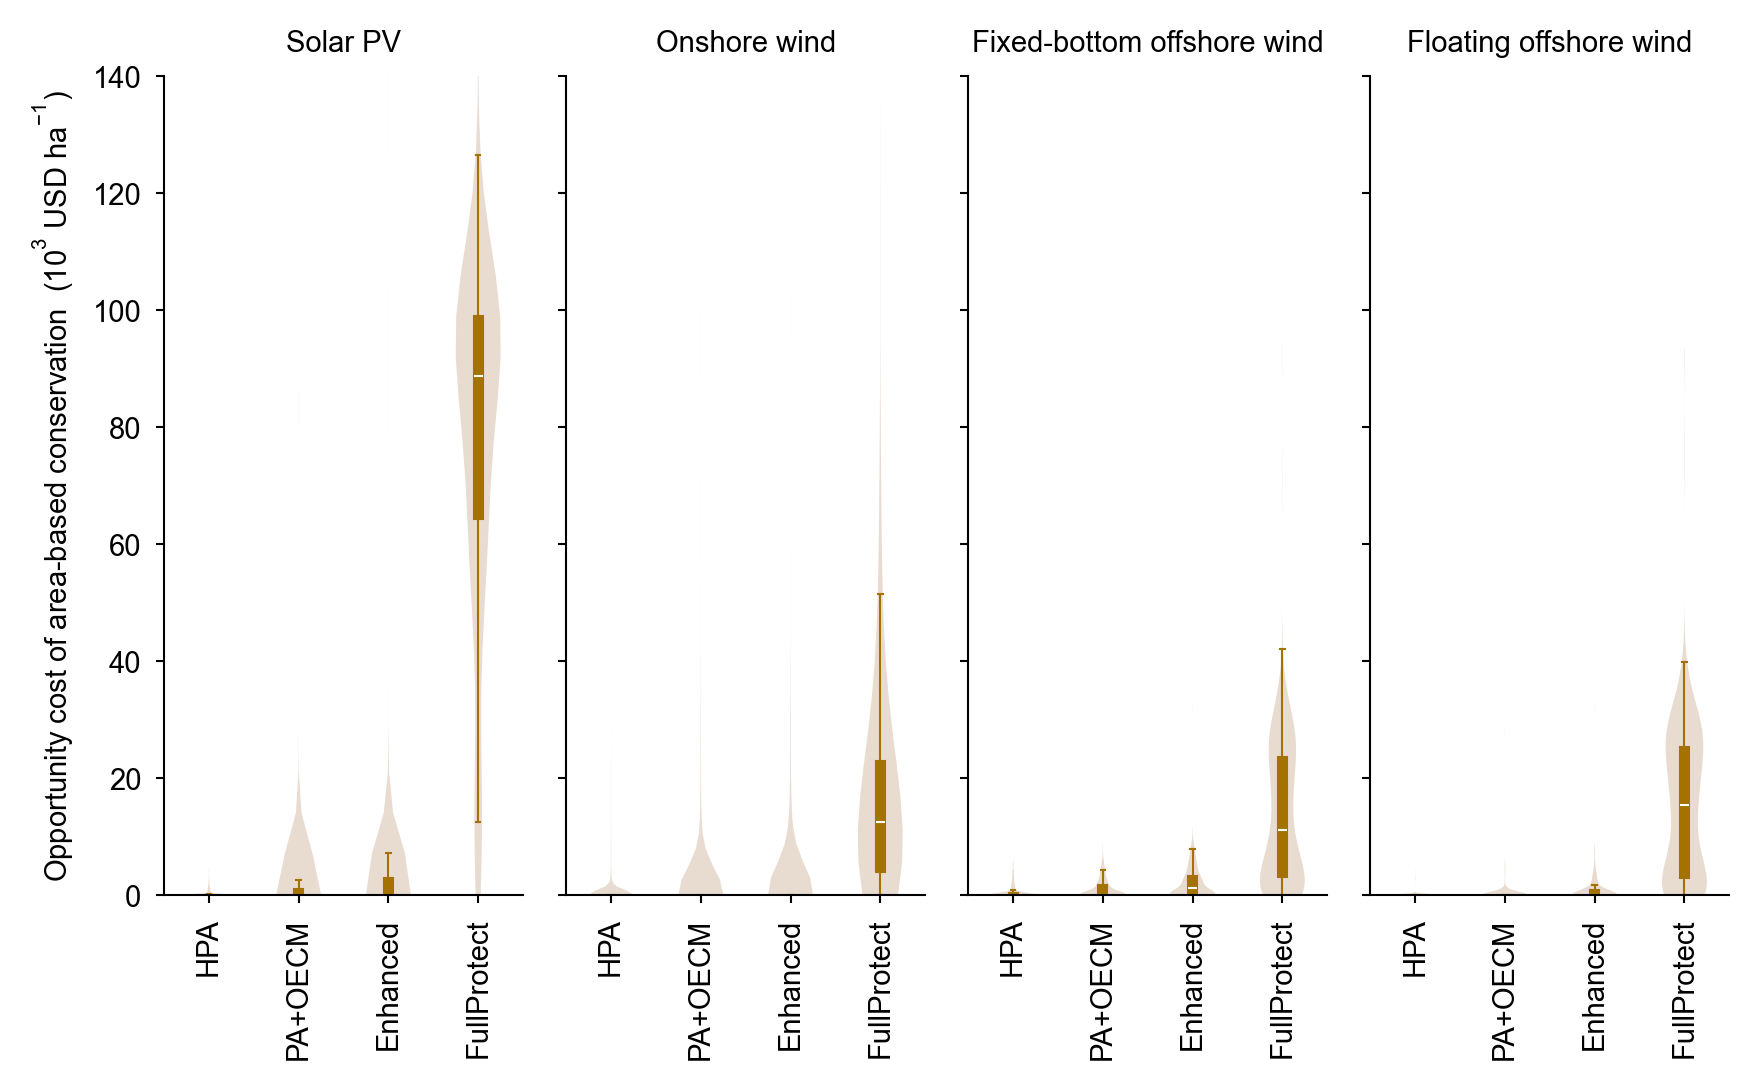

In [38]:
# Box plot

# Chart paramter
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['axes.linewidth'] = 0.5


VRE = ['solar','onwin','of-fx','of-fl']
CASES = ['base','low','mid','high']
CASE_DICT = {'base':'HPA','low':'PA+OECM','mid':'Enhanced','high':'FullProtect'}
TECH_CASE = 'ccs-biomass'

fig, axes = plt.subplots(1, len(VRE), gridspec_kw={'wspace':0.12}, figsize=[MAX_WIDTH*0.95,MAX_WIDTH*0.5], dpi=300, sharey=True)
    
for i, res in enumerate(VRE):
    df_vre_km2 = pd.DataFrame()
    df_system_cost = pd.DataFrame(index=CASES, columns=VRE)
    box_color = "#A37200"

    for case in CASES:
        case_name = get_model_name(potential_case=case, tech_case=TECH_CASE)
        if os.path.isfile(f'output/{case_name}/renewable_USD-ha_{case_name}.csv'):
            df_vre_km2[case] = pd.read_csv(f'output/{case_name}/renewable_USD-ha_{case_name}.csv', index_col=0)[res] / 1000#/ USD #M-JPY/km2 -> USD/km2
        else:
            print("No data:", case_name)

    df_vre_km2 = df_vre_km2[~np.isnan(df_vre_km2['low'])]
    axes[i].boxplot(df_vre_km2, positions=[0,1,2,3], widths=0.1,
                    patch_artist=True,
                    boxprops=dict(facecolor=box_color, color=box_color, linewidth=0.5),
                    whiskerprops=dict(color=box_color, linewidth=0.5),
                    capprops=dict(color=box_color, linewidth=0.5),
                    medianprops=dict(color='#fff', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=0))
    violin = axes[i].violinplot(df_vre_km2, positions=[0,1,2,3], widths=0.5, bw_method="scott", showmeans=False, showextrema=False, showmedians=False)

    for body in violin['bodies']:
        body.set_color("#B58866")
        body.set_edgecolor("none")

    axes[i].set_title(P['name'][res], fontsize=7)
    axes[i].set_ylim(0, 140)
    axes[i].set_xticklabels([CASE_DICT[case] for case in CASES], rotation=90)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

axes[0].set_ylabel('Opportunity cost of area-based conservation  (10$^{3}$ USD ha$^{-1}$)')

plt.savefig(f"output/analysis/MOC_comparison_{TECH_CASE}.png", bbox_inches='tight', pad_inches=0, transparent=False, dpi=900)
plt.savefig(f"output/analysis/MOC_comparison_{TECH_CASE}.pdf", bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()